
# CNN Vision Basics

## Goal

I wanted a cleaner set of notes for the main intuition behind convolutional neural networks before jumping into TensorFlow code. This notebook keeps the idea visual: a filter slides over an image, produces a feature map, and pooling keeps the strongest local patterns while shrinking the representation.


In [1]:

import numpy as np
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-whitegrid')
np.set_printoptions(suppress=True)


def annotate_heatmap(ax, matrix, title, cmap='viridis'):
    ax.imshow(matrix, cmap=cmap)
    ax.set_title(title)
    ax.set_xticks(range(matrix.shape[1]))
    ax.set_yticks(range(matrix.shape[0]))
    threshold = float(matrix.mean())
    for i in range(matrix.shape[0]):
        for j in range(matrix.shape[1]):
            color = 'white' if matrix[i, j] > threshold else 'black'
            ax.text(j, i, f"{matrix[i, j]:.1f}", ha='center', va='center', color=color, fontsize=9)



## Image And Kernels

A grayscale image can be treated like a matrix. A kernel is just a smaller matrix of weights. Each time the kernel lands on a local patch, we multiply element by element and sum the result. That single sum becomes one value in the next feature map.


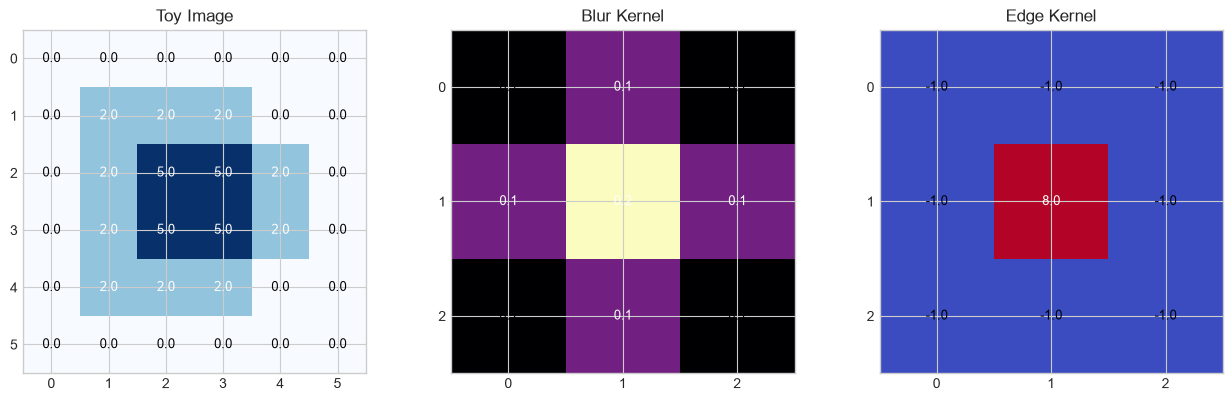

In [2]:

image = np.array([
    [0, 0, 0, 0, 0, 0],
    [0, 2, 2, 2, 0, 0],
    [0, 2, 5, 5, 2, 0],
    [0, 2, 5, 5, 2, 0],
    [0, 2, 2, 2, 0, 0],
    [0, 0, 0, 0, 0, 0],
], dtype=float)

blur_kernel = np.array([
    [1, 2, 1],
    [2, 4, 2],
    [1, 2, 1],
], dtype=float) / 16

edge_kernel = np.array([
    [-1, -1, -1],
    [-1,  8, -1],
    [-1, -1, -1],
], dtype=float)

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
annotate_heatmap(axes[0], image, 'Toy Image', cmap='Blues')
annotate_heatmap(axes[1], blur_kernel, 'Blur Kernel', cmap='magma')
annotate_heatmap(axes[2], edge_kernel, 'Edge Kernel', cmap='coolwarm')
plt.tight_layout()



## Convolution Step By Step

The function below uses a valid convolution, which means the filter stays fully inside the image. In practice, CNN libraries also let us add padding so the borders are preserved more carefully.


Top-left blur calculation:
[[0. 0. 0.]
 [0. 2. 2.]
 [0. 2. 5.]]

Weighted sum = 1.3125


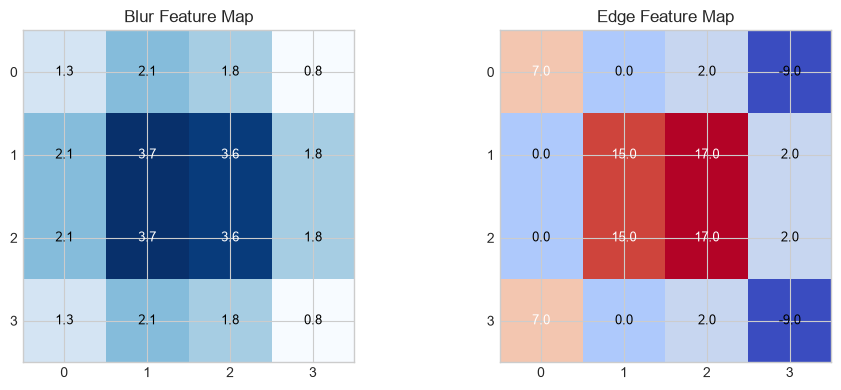

In [3]:

def conv2d_valid(matrix, kernel, stride=1):
    kernel = np.asarray(kernel)
    out_rows = (matrix.shape[0] - kernel.shape[0]) // stride + 1
    out_cols = (matrix.shape[1] - kernel.shape[1]) // stride + 1
    output = np.zeros((out_rows, out_cols), dtype=float)
    for r in range(out_rows):
        for c in range(out_cols):
            window = matrix[r * stride:r * stride + kernel.shape[0], c * stride:c * stride + kernel.shape[1]]
            output[r, c] = np.sum(window * kernel)
    return output

blur_map = conv2d_valid(image, blur_kernel)
edge_map = conv2d_valid(image, edge_kernel)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
annotate_heatmap(axes[0], blur_map, 'Blur Feature Map', cmap='Blues')
annotate_heatmap(axes[1], edge_map, 'Edge Feature Map', cmap='coolwarm')
plt.tight_layout()

print('Top-left blur calculation:')
window = image[:3, :3]
print(window)
print()
print('Weighted sum =', np.sum(window * blur_kernel))



## Stride Changes Resolution

Stride controls how far the kernel moves each time. A stride of 1 keeps more detail. A stride of 2 skips positions, which gives a smaller feature map but throws away some local information.


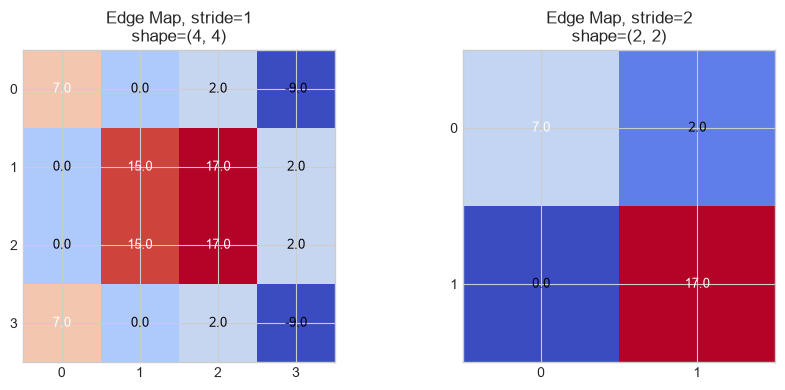

In [4]:

stride1 = conv2d_valid(image, edge_kernel, stride=1)
stride2 = conv2d_valid(image, edge_kernel, stride=2)
title1 = f"Edge Map, stride=1{chr(10)}shape={stride1.shape}"
title2 = f"Edge Map, stride=2{chr(10)}shape={stride2.shape}"

fig, axes = plt.subplots(1, 2, figsize=(9, 4))
annotate_heatmap(axes[0], stride1, title1, cmap='coolwarm')
annotate_heatmap(axes[1], stride2, title2, cmap='coolwarm')
plt.tight_layout()



## Pooling

Pooling layers downsample a feature map. Max pooling keeps the strongest activation inside each local window, while average pooling keeps the local average. Both reduce width and height, which helps later layers work with fewer values.


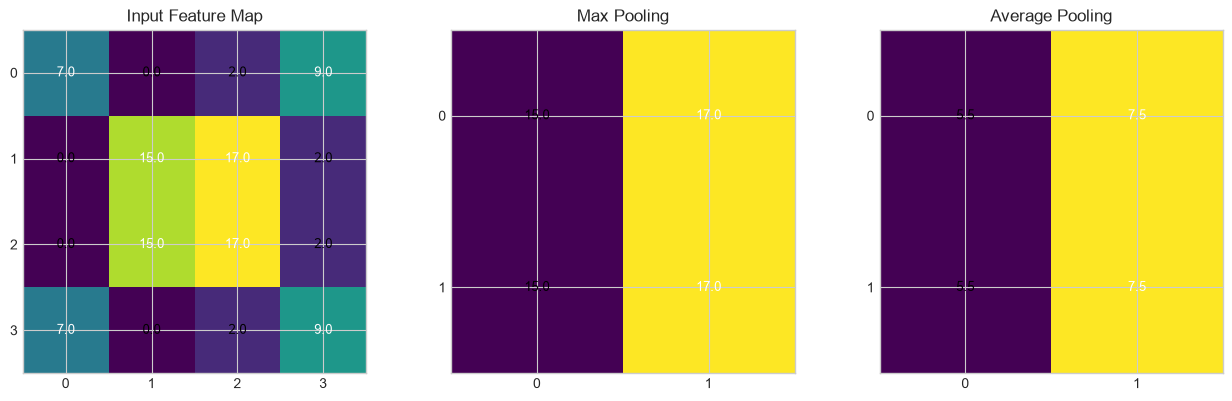

In [5]:

def pool2d(matrix, size=2, stride=2, mode='max'):
    out_rows = (matrix.shape[0] - size) // stride + 1
    out_cols = (matrix.shape[1] - size) // stride + 1
    output = np.zeros((out_rows, out_cols), dtype=float)
    for r in range(out_rows):
        for c in range(out_cols):
            window = matrix[r * stride:r * stride + size, c * stride:c * stride + size]
            output[r, c] = window.max() if mode == 'max' else window.mean()
    return output

max_pool = pool2d(np.abs(edge_map), mode='max')
avg_pool = pool2d(np.abs(edge_map), mode='avg')

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
annotate_heatmap(axes[0], np.abs(edge_map), 'Input Feature Map', cmap='viridis')
annotate_heatmap(axes[1], max_pool, 'Max Pooling', cmap='viridis')
annotate_heatmap(axes[2], avg_pool, 'Average Pooling', cmap='viridis')
plt.tight_layout()



## Why CNN Layers Scale Better Than Dense Layers

A dense layer connected directly to a `28 x 28` image has one weight per input pixel for each hidden unit. A convolutional layer reuses the same small kernel across the whole image, so the number of learned weights is much smaller.


In [6]:

image_pixels = 28 * 28
hidden_units = 128

dense_params = image_pixels * hidden_units + hidden_units
conv_filters = 16
kernel_size = 3
conv_params = kernel_size * kernel_size * conv_filters + conv_filters

print(f'Dense layer params for a 28x28 input -> 128 units: {dense_params:,}')
print(f'Conv layer params for 16 filters of size 3x3: {conv_params:,}')
print(f'Parameter reduction factor: {dense_params / conv_params:.1f}x')


Dense layer params for a 28x28 input -> 128 units: 100,480
Conv layer params for 16 filters of size 3x3: 160
Parameter reduction factor: 628.0x



## What I Learned

- Convolution is a repeated local weighted sum, not a fully connected interaction with the whole image at once.
- Different kernels highlight different patterns such as blur, edges, or texture.
- Stride and pooling both shrink the representation, but they do it in different ways.
- CNNs stay practical because the same small kernel is reused across many image regions.

## Limits

These notes focus on intuition only. They do not train a real CNN, cover padding modes in depth, or compare learned filters from an actual dataset.
